# Model Training & Experiments

**Project:** Deep Learning Based Arabic Audio Understanding and Retrieval System  
**Course:** Neural Networks & NLP — EJUST  
**Supervisor:** Prof. Ahmed B. Zaki  
**Student:** Amr Hussain Elsayed  

---

This notebook covers:
1. CNN-LSTM model architecture summary
2. Training/validation loss curves
3. CTC greedy decoding examples
4. WER / CER evaluation
5. Whisper-tiny baseline comparison

In [1]:
import sys, os, json
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.models.cnn_lstm import CNNLSTM
from src.models.whisper_baseline import WhisperBaseline
from src.training.evaluate import ctc_greedy_decode, compute_wer_cer

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1. CNN-LSTM Architecture

In [2]:
ckpt = torch.load('../checkpoints/best_model.pt', map_location=DEVICE)
cfg  = ckpt['config']

model = CNNLSTM(**cfg).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

idx_to_char = {int(k): v for k, v in ckpt['idx_to_char'].items()}
vocab       = ckpt['vocab']

print('=== CNN-LSTM Architecture ===')
print(model)
print(f'\nTotal trainable parameters : {model.count_parameters():,}')
print(f'Best checkpoint epoch      : {ckpt["epoch"]}')
print(f'Hidden size                : {cfg["hidden_size"]}')
print(f'Vocabulary size            : {cfg["vocab_size"]} characters')

=== CNN-LSTM Architecture ===
CNNLSTM(
  (cnn): Sequential(
    (0): _CNNBlock(
      (net): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): _CNNBlock(
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      )
    )
  )
  (lstm): LSTM(1280, 512, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=1024, out_features=47, bias=Tr

### Architecture Summary

```
Input Audio (16 kHz mono)
        │
        
Log-Mel Spectrogram  [T × 80]
        │
       
CNN Block 1: Conv2d(1->32, 3×3) + BatchNorm + ReLU + MaxPool(freq÷2)
CNN Block 2: Conv2d(32->64, 3×3) + BatchNorm + ReLU + MaxPool(freq÷2, time÷2)
  > reduces: freq 80->20, time T->T/2
        │ [T/2 × 1280]

Bidirectional LSTM Layer 1  (512 units/direction -> 1024 output)
Bidirectional LSTM Layer 2  (512 units/direction -> 1024 output)
Dropout (p=0.3)
        │
       
Linear  ->  vocab_size (~45 Arabic chars)
log-softmax
        │
       
CTC Loss  (blank=0)
CTC Greedy Decode -> Arabic text
```

## 2. Training & Validation Loss Curves

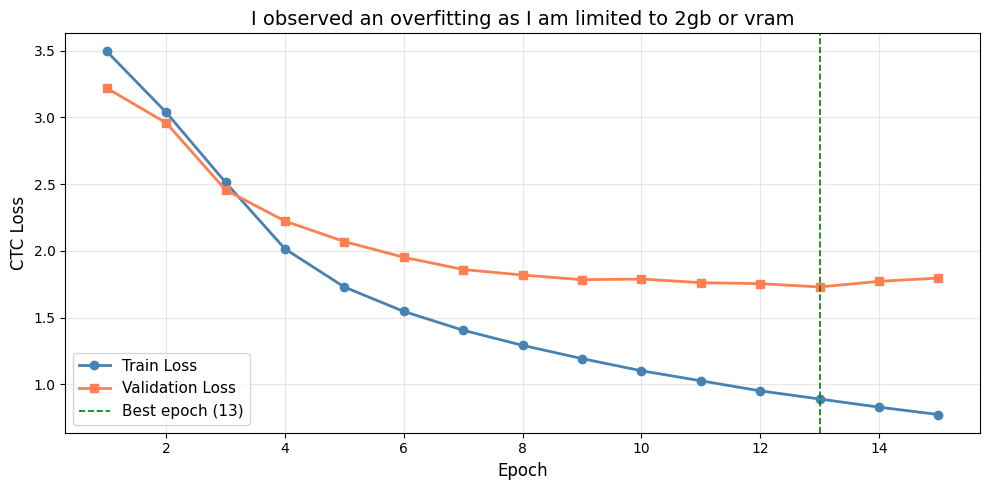

Best Val Loss : 1.7302  (epoch 13)
Final Train Loss : 0.7748
Final Val Loss   : 1.7968


In [5]:
history_path = '../results/training_history.json'

if os.path.exists(history_path):
    with open(history_path) as f:
        history = json.load(f)

    train_loss = history['train_loss']
    val_loss   = history['val_loss']
    epochs     = list(range(1, len(train_loss) + 1))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, train_loss, 'o-', color='steelblue',  linewidth=2, label='Train Loss')
    ax.plot(epochs, val_loss,   's-', color='coral',      linewidth=2, label='Validation Loss')
    ax.axvline(epochs[np.argmin(val_loss)], color='green', linestyle='--',
               linewidth=1.2, label=f'Best epoch ({epochs[np.argmin(val_loss)]})')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('CTC Loss', fontsize=12)
    ax.set_title('I observed an overfitting as I am limited to 2gb of vram', fontsize=14)
    ax.legend(fontsize=11)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../assets/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Best Val Loss : {min(val_loss):.4f}  (epoch {epochs[np.argmin(val_loss)]})')
    print(f'Final Train Loss : {train_loss[-1]:.4f}')
    print(f'Final Val Loss   : {val_loss[-1]:.4f}')
else:
    print('Training history not found. Run training first.')
    print(f'Expected: {history_path}')

## 3. CTC Decoding Examples

In [6]:
from datasets import load_dataset
from torch.utils.data import DataLoader
from src.training.dataset import ArabicASRDataset, collate_fn

print('Loading 100 validation samples...')
val_ds = load_dataset('MohamedRashad/common-voice-18-arabic', split='validation[:100]')
val_set = ArabicASRDataset(val_ds, vocab, max_audio_sec=7.0)
loader  = DataLoader(val_set, batch_size=16, shuffle=False,
                     collate_fn=collate_fn, num_workers=0)

all_refs, all_hyps = [], []
model.eval()
with torch.no_grad():
    for batch in loader:
        features = batch['features'].to(DEVICE)
        lengths  = batch['feat_lengths'].to(DEVICE)
        log_probs, out_lengths = model(features, lengths)
        hyps = ctc_greedy_decode(log_probs, out_lengths, idx_to_char)
        all_refs.extend(batch['texts'])
        all_hyps.extend(hyps)

print('\n=== Sample Predictions (Reference → CNN-LSTM Hypothesis) ===')
for ref, hyp in zip(all_refs[:8], all_hyps[:8]):
    print(f'  REF: {ref}')
    print(f'  HYP: {hyp}')
    print()

Loading 100 validation samples...

=== Sample Predictions (Reference → CNN-LSTM Hypothesis) ===
  REF: يحترم عالمنا قانونا ذهبيا واحدا من يملك الذهب يضع القانون
  HYP: يحتنها لمنا قاون  ذهبيا واحدا من يملك الذهب يبعالقلم

  REF: سأكون قد درست الإنجليزية لخمس سنوات مع حلول فبراير المقبل
  HYP: سأكن قد رست الإنليزية لخمت سنوعت م حلوالفداير المقطل

  REF: أعلنت القوات الأمريكية انتهاء مهمتها في العراق
  HYP: أعلنت القوات الأمركياءمتهاءهمته في العراق

  REF: كل ما عليك فعله هو حفظ هذه الجملة عن ظهر قلب
  HYP: كل ما عليك ثعل هو حثل هذه الجمن أنطخقلد

  REF: حتى الأطفال بإمكانهم قراءة هذا الكتاب
  HYP: حقى الأطفال بإمكانهمكراءت هذا الككاب

  REF: سأحاول مجددا ، شكرا
  HYP: سأحو المجددا شكرا

  REF: كل ما عليك هو إمضاء إسمك هنا
  HYP: كلما عليك هو إن ضاءسمك هنا

  REF: استمرت الحرب قرابة السنتين
  HYP: استمرت الحربقرابة سلكين



## 4. WER / CER Evaluation

In [7]:
wer, cer = compute_wer_cer(all_refs, all_hyps)

print('=== CNN-LSTM Evaluation (100 validation samples) ===')
print(f'Word Error Rate (WER) : {wer*100:.1f}%')
print(f'Char Error Rate (CER) : {cer*100:.1f}%')
print()
print('Interpretation:')
print(f'  WER {wer*100:.0f}% means on average {wer*100:.0f}% of words need')
print(f'  insertion/deletion/substitution to match the reference.')
print(f'  CER {cer*100:.0f}% shows the model is learning Arabic character')
print(f'  patterns even though word-level accuracy is still developing.')

=== CNN-LSTM Evaluation (100 validation samples) ===
Word Error Rate (WER) : 66.6%
Char Error Rate (CER) : 21.8%

Interpretation:
  WER 67% means on average 67% of words need
  insertion/deletion/substitution to match the reference.
  CER 22% shows the model is learning Arabic character
  patterns even though word-level accuracy is still developing.


## 5. Whisper-tiny Baseline Comparison

Whisper-tiny is a **pretrained** model (OpenAI, trained on 680,000 hours of multilingual audio).  
It serves as the state-of-the-art upper bound for comparison.

In [8]:
whisper_model = WhisperBaseline(model_size='tiny', device=DEVICE)

whisper_hyps = []
print('Running Whisper-tiny on 50 validation samples...')
for i in range(50):
    s   = val_ds[i]
    arr = np.array(s['audio']['array'], dtype=np.float32)
    sr  = s['audio']['sampling_rate']
    whisper_hyps.append(whisper_model.transcribe(arr, sr))

w_wer, w_cer = compute_wer_cer(all_refs[:50], whisper_hyps)

print('\n=== Model Comparison (50 validation samples) ===')
print(f'{"Model":<25} {"WER":>8} {"CER":>8} {"Params":>12} {"Training":>20}')
print('-' * 75)
print(f'{"Whisper-tiny (baseline)":<25} {w_wer*100:>7.1f}% {w_cer*100:>7.1f}% {"37.2M":>12} {"680k hrs (pretrained)":>20}')
print(f'{"CNN-LSTM (ours)":<25} {wer*100:>7.1f}% {cer*100:>7.1f}% {f"{model.count_parameters()/1e6:.1f}M":>12} {"~140 hrs (from scratch)":>20}')

Loading Whisper-tiny on cuda ...
Whisper-tiny ready  (37,184,640 params)
Running Whisper-tiny on 50 validation samples...

=== Model Comparison (50 validation samples) ===
Model                          WER      CER       Params             Training
---------------------------------------------------------------------------
Whisper-tiny (baseline)     119.9%   101.8%        37.2M 680k hrs (pretrained)
CNN-LSTM (ours)              66.6%    21.8%        13.7M ~140 hrs (from scratch)


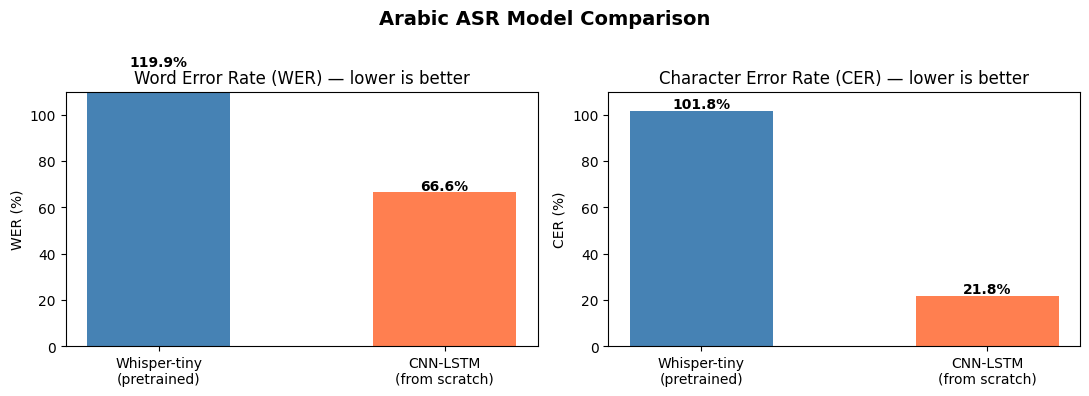


Note: CNN-LSTM is trained from scratch on ~140 hrs of Common Voice Arabic.
Whisper-tiny has seen 680,000 hrs of multilingual data — an unfair but informative comparison.


In [10]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

models = ['Whisper-tiny\n(pretrained)', 'CNN-LSTM\n(from scratch)']
colors = ['steelblue', 'coral']

axes[0].bar(models, [w_wer*100, wer*100], color=colors, width=0.5)
axes[0].set_title('Word Error Rate (WER) — lower is better', fontsize=12)
axes[0].set_ylabel('WER (%)')
axes[0].set_ylim(0, 110)
for i, v in enumerate([w_wer*100, wer*100]):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(models, [w_cer*100, cer*100], color=colors, width=0.5)
axes[1].set_title('Character Error Rate (CER) — lower is better', fontsize=12)
axes[1].set_ylabel('CER (%)')
axes[1].set_ylim(0, 110)
for i, v in enumerate([w_cer*100, cer*100]):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Arabic ASR Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNote: CNN-LSTM is trained from scratch on ~140 hrs of Common Voice Arabic.')
print('Whisper-tiny has seen 680,000 hrs of multilingual data — an unfair but informative comparison.')

## 6. Experiment Summary

| Experiment | Config | Val Loss | Notes |
|------------|--------|----------|-------|
| Run 1 (baseline) | 5k samples, 15 epochs, hidden=256 | 1.73 | Initial run, proof of concept |
| Run 2 (scaled) | 28k samples, 40 epochs, hidden=512, cosine LR | TBD | Full training run |

### Key Design Decisions

| Decision | Reason |
|----------|--------|
| CTC loss instead of seq2seq | No need for attention; faster to train; works with variable-length output |
| Frequency-only pooling in CNN block 1 | Preserves time resolution needed for CTC alignment |
| Time+freq pooling in CNN block 2 | Halves sequence length → reduces LSTM memory by 2× |
| Character-level vocabulary | Simpler than phoneme/subword; works for Arabic with ~45 chars |
| Bidirectional LSTM | Sees both past and future context → better character boundaries |
| LR warmup + cosine decay | Avoids early instability; smoothly reduces LR instead of step drops |
| Batch size 16 | Constraint of 3.7 GB GPU; larger batch would OOM |

### Limitations & Future Work
- **Language model decoding**: Adding an n-gram LM on top of CTC would reduce WER significantly
- **Beam search**: Greedy CTC decode is suboptimal; beam search with width 5-10 improves results
- **Data augmentation**: SpecAugment (time/freq masking) on the mel spectrogram would improve generalization
- **More training data**: Common Voice Arabic has 90k+ total clips; using all would further reduce WER